# Obesity

In [1]:
import pandas as pd
import numpy as np

ds_url = "https://raw.githubusercontent.com/aap-unlp/datasets/main/obesity_uci/obesity_uci.csv"

try:
    df = pd.read_csv(ds_url)
    print(f"✅ Dataset cargado exitosamente!")
    print(f"\n🔍 Primeras 5 filas:")
    display(df.head(5))
except Exception as e:
    print(f"❌ Error al cargar: {e}")

✅ Dataset cargado exitosamente!

🔍 Primeras 5 filas:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


# Ejercicio 5

C:\Users\gonza\AppData\Local\Temp\ipykernel_17264\3966685675.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=fam_his_weight, x=weight_data, palette='Set2', width=0.5)


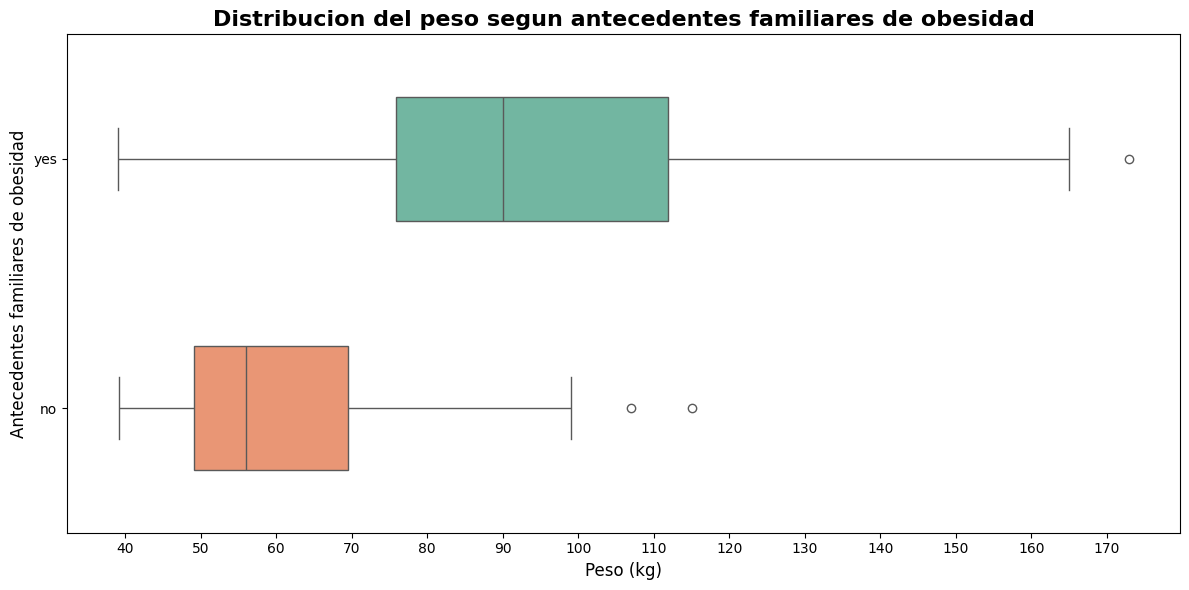

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

# Calcular medidas
weight_data = df['Weight'].dropna()
q1 = weight_data.quantile(0.25)
q2 = weight_data.quantile(0.50)
q3 = weight_data.quantile(0.75)
iqr = q3 - q1
fam_his_weight = df['family_history_with_overweight'].dropna()

# Configurar el estilo
plt.figure(figsize=(12, 6))
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.3

# Crear diagrama de caja
sns.boxplot(y=fam_his_weight, x=weight_data, palette='Set2', width=0.5)
plt.gca().xaxis.set_major_locator(MultipleLocator(10))
plt.title('Distribucion del peso segun antecedentes familiares de obesidad',
          fontsize=16, fontweight='bold')
plt.xlabel('Peso (kg)', fontsize=12)
plt.ylabel('Antecedentes familiares de obesidad', fontsize=12)

plt.tight_layout()
plt.show()

In [3]:

# Calcular los estadísticos por categoría
summary = {}
for cat, subset in df.groupby("family_history_with_overweight")["Weight"]:
    q1 = subset.quantile(0.25)
    q2 = subset.quantile(0.50)
    q3 = subset.quantile(0.75)
    iqr = q3 - q1
    lower_whisker = subset[subset >= q1 - 1.5*iqr].min()
    upper_whisker = subset[subset <= q3 + 1.5*iqr].max()

    summary[cat] = [
        subset.min(),
        subset.max(),
        q1,
        q2,
        q3,
        iqr,
        lower_whisker,
        upper_whisker
    ]

# Crear DataFrame con los resultados
tabla = pd.DataFrame(
    summary,
    index=[
        "Mínimo",
        "Máximo",
        "Q1",
        "Q2 (Mediana)",
        "Q3",
        "RIC",
        "Bigote Inferior",
        "Bigote Superior"
    ]
)

print(tabla)

                         no         yes
Mínimo            39.101805   39.000000
Máximo           115.000000  173.000000
Q1                49.039794   75.851219
Q2 (Mediana)      56.000000   89.986675
Q3                69.500000  111.839011
RIC               20.460206   35.987792
Bigote Inferior   39.101805   39.000000
Bigote Superior   99.000000  165.057269


# Titanic

In [4]:
# Cargar el dataset
url = "https://raw.githubusercontent.com/aap-unlp/datasets/main/titanic/titanic.csv"

try:
    df = pd.read_csv(url)
    print(f"✅ Dataset cargado exitosamente!")
    print(f"📊 Dimensiones: {df.shape}")
    display(f"📋 Columnas: {list(df.columns)}")
except Exception as e:
    print(f"❌ Error al cargar: {e}")

✅ Dataset cargado exitosamente!
📊 Dimensiones: (891, 12)


"📋 Columnas: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']"

# Ejercicio 7

In [5]:
# Imprimir primeras 5 filas y resumen estadistico
print(f"\n🔍 Primeras 5 filas:")
display(df.head(5))
print(f"\n Resumen estadistico:")
display(df.drop(columns=['PassengerId', 'Survived']).describe())


🔍 Primeras 5 filas:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



 Resumen estadistico:


,Pclass,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,2.000000,20.125000,0.000000,0.000000,7.910400
50%,3.000000,28.000000,0.000000,0.000000,14.454200
75%,3.000000,38.000000,1.000000,0.000000,31.000000
max,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# Número de nulos por columna
nulos = df.isnull().sum()

# Porcentaje de nulos por columna
porcentaje_nulos = (df.isnull().mean() * 100).round(2)

# Unir ambos en un DataFrame
resumen_nulos = pd.DataFrame({
    "Nulos": nulos,
    "Porcentaje": porcentaje_nulos
})

# Filtrar solo las columnas que tienen nulos
resumen_nulos = resumen_nulos[resumen_nulos["Nulos"] > 0]

print(resumen_nulos)

          Nulos  Porcentaje
Age         177       19.87
Cabin       687       77.10
Embarked      2        0.22


In [7]:
df['Title'] = df['Name'].str.extract(r', ([^\.]+)\.', expand=False)

display(df.head(5))

# Mostrar resultados
print("Títulos extraídos:")
print(df['Title'].value_counts())

# Verificar cuántos NO tienen título (son NaN)
missing_titles = df['Title'].isnull().sum()
print(f"\nNúmero de filas sin título: {missing_titles}")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr


Títulos extraídos:
Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

Número de filas sin título: 0


In [8]:
# Diccionario de reemplazo
title_map = {
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs",
    "Mr": "Mr",
    "Miss": "Miss",
    "Mrs": "Mrs",
    "Master": "Master"
}

# Reemplazar y unificar
df["Title"] = df["Title"].map(title_map).fillna("Others")

df["Title"].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Others     23
Name: count, dtype: int64

In [9]:
# Verificar valores faltantes antes y después
print("Valores faltantes en 'Age' ANTES de imputar:", df['Age'].isnull().sum())

# Imputar edad por promedio del grupo
df['Age'] = df['Age'].fillna(df.groupby('Title')['Age'].transform('mean'))

# Verificar después
print("Valores faltantes en 'Age' DESPUÉS de imputar:", df['Age'].isnull().sum())

Valores faltantes en 'Age' ANTES de imputar: 177
Valores faltantes en 'Age' DESPUÉS de imputar: 0


In [10]:
# Cambio nulos de Cabin por Desconocido
print("Valores faltantes en 'Cabin' ANTES de imputar:", df['Cabin'].isnull().sum())
df['Cabin'] = df['Cabin'].fillna('Desconocido')
print("Valores faltantes en 'Cabin' DESPUÉS de imputar:", df['Cabin'].isnull().sum())

# Cambio nulos de Embarked por la moda
print("Valores faltantes en 'Embarked' ANTES de imputar:", df['Embarked'].isnull().sum())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print("Valores faltantes en 'Embarked' DESPUÉS de imputar:", df['Embarked'].isnull().sum())      

# Ultima revision de nulos
display(df.isnull().sum())

Valores faltantes en 'Cabin' ANTES de imputar: 687
Valores faltantes en 'Cabin' DESPUÉS de imputar: 0
Valores faltantes en 'Embarked' ANTES de imputar: 2
Valores faltantes en 'Embarked' DESPUÉS de imputar: 0


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
Title          0
dtype: int64

In [11]:
# Agrego FamilySize
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Desconocido,S,Mr,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Desconocido,S,Miss,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Desconocido,S,Mr,1


In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Numerizo Sex
df['Sex'] = le.fit_transform(df['Sex'])

# Numerizo Embarked
df['Embarked'] = le.fit_transform(df['Embarked'])

#Numerizo Title
df['Title'] = le.fit_transform(df['Title'])

display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,Desconocido,2,2,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,0,3,2
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,Desconocido,2,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,2,3,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,Desconocido,2,2,1


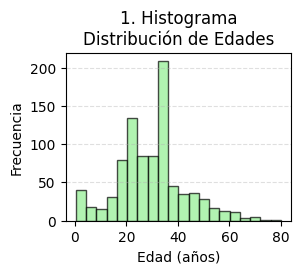

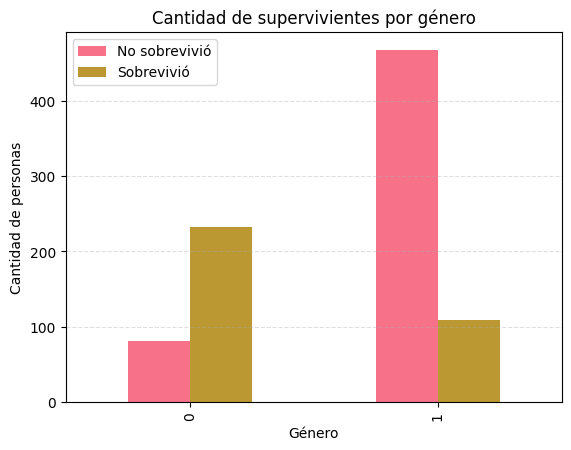

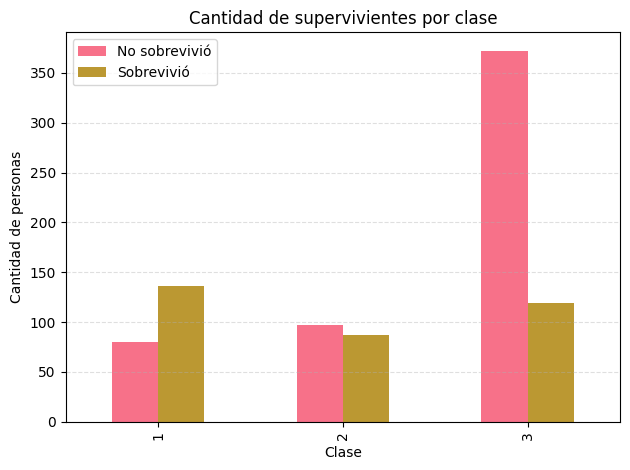

In [13]:
# Configurar estilo
plt.style.use('default')
sns.set_palette("husl")

# 1. Histograma de Age

plt.subplot(2, 2, 2)
plt.hist(df['Age'], bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
plt.title('1. Histograma\nDistribución de Edades')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia')
plt.grid(axis='y',alpha=0.4, linestyle='--')

# 2. Grafico de barras de Survive por Sex
gender_counts = df.groupby(["Sex", "Survived"]).size().unstack()
gender_counts.plot(kind="bar")
plt.title("Cantidad de supervivientes por género")
plt.xlabel("Género")
plt.ylabel("Cantidad de personas")
plt.legend(["No sobrevivió", "Sobrevivió"])
plt.grid(axis='y',alpha=0.4, linestyle='--')

# 3. Grafico de barras de Survive por Pclass
class_counts = df.groupby(["Pclass", "Survived"]).size().unstack()
class_counts.plot(kind="bar")
plt.title("Cantidad de supervivientes por clase")
plt.xlabel("Clase")
plt.ylabel("Cantidad de personas")
plt.legend(["No sobrevivió", "Sobrevivió"])
plt.grid(axis='y',alpha=0.4, linestyle='--') 

plt.tight_layout()
plt.show()

# Ejercicio 8

In [14]:
# Correlación entre Fare y Pclass
corr = df["Fare"].corr(df["Pclass"])
print("Correlación entre Fare y Pclass:", corr)


Correlación entre Fare y Pclass: -0.5494996199439082


# Ejercicio 10

In [15]:
# Creo dataframe
df = pd.DataFrame({
    "Altura": [1.65, 1.81, 1.70, 1.62, 1.74, 1.70, 1.80, 1.73, 1.68],
    "Peso": [75, 86, 82, 78, 77, 87, 90, 83, 80]
})

display(df)

,Altura,Peso
0,1.65,75
1,1.81,86
2,1.70,82
3,1.62,78
4,1.74,77
5,1.70,87
6,1.80,90
7,1.73,83
8,1.68,80


In [16]:
# Guardo variables de Altura
minAltura = df['Altura'].min()
maxAltura = df['Altura'].max()
mediaAltura = df['Altura'].mean()
desvioAltura = df['Altura'].std()
q1Altura = df['Altura'].quantile(0.25)
q3Altura = df['Altura'].quantile(0.75)
ircAltura = q3Altura - q1Altura

# Guardo variables de Peso
minPeso = df['Peso'].min()
maxPeso = df['Peso'].max()
mediaPeso = df['Peso'].mean()
desvioPeso = df['Peso'].std()
q1Peso = df['Peso'].quantile(0.25)
q3Peso = df['Peso'].quantile(0.75)
ircPeso = q3Peso - q1Peso

#Normalizo por MinMax
df['AlturaLineal']= (df['Altura']-minAltura)/(maxAltura-minAltura)
df['PesoLineal']= (df['Peso']-minPeso)/(maxPeso-minPeso)

# Normalizo Standard
df['AlturaEstandar']= (df['Altura']-mediaAltura)/desvioAltura
df['PesoEstandar']= (df['Peso']-mediaPeso)/desvioPeso

# Normalizo Robust
df['AlturaRobust']= (df['Altura']-q1Altura)/ircAltura
df['PesoRobust']= (df['Peso']-q1Peso)/ircPeso

display(df)

,Altura,Peso,AlturaLineal,PesoLineal,AlturaEstandar,PesoEstandar,AlturaRobust,PesoRobust
0,1.65,75,0.157895,0.000000,-1.018603,-1.4,-0.500000,-0.375
1,1.81,86,1.000000,0.733333,1.510342,0.8,2.166667,1.000
2,1.70,82,0.421053,0.466667,-0.228307,0.0,0.333333,0.500
3,1.62,78,0.000000,0.200000,-1.492780,-0.8,-1.000000,0.000
4,1.74,77,0.631579,0.133333,0.403929,-1.0,1.000000,-0.125
5,1.70,87,0.421053,0.800000,-0.228307,1.0,0.333333,1.125
6,1.80,90,0.947368,1.000000,1.352283,1.6,2.000000,1.500
7,1.73,83,0.578947,0.533333,0.245870,0.2,0.833333,0.625
8,1.68,80,0.315789,0.333333,-0.544425,-0.4,0.000000,0.250


C:\Users\gonza\AppData\Local\Temp\ipykernel_17264\2206684606.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y="atributo", x="valor", data=df_melt_altura, palette="Set2")


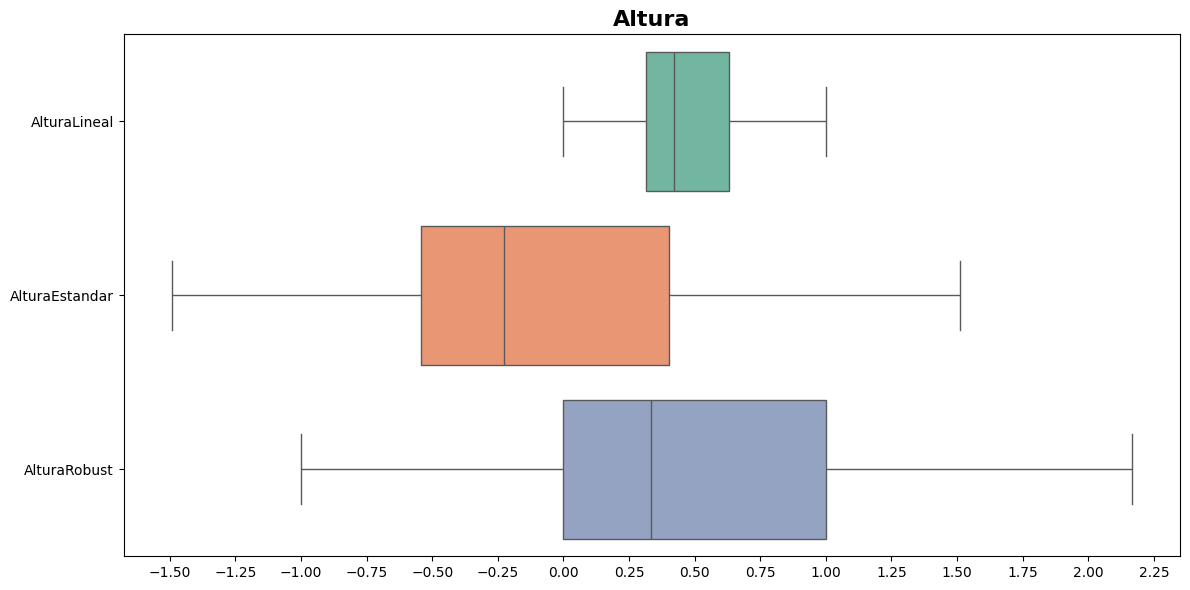

C:\Users\gonza\AppData\Local\Temp\ipykernel_17264\2206684606.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y="atributo", x="valor", data=df_melt_peso, palette="Set2")


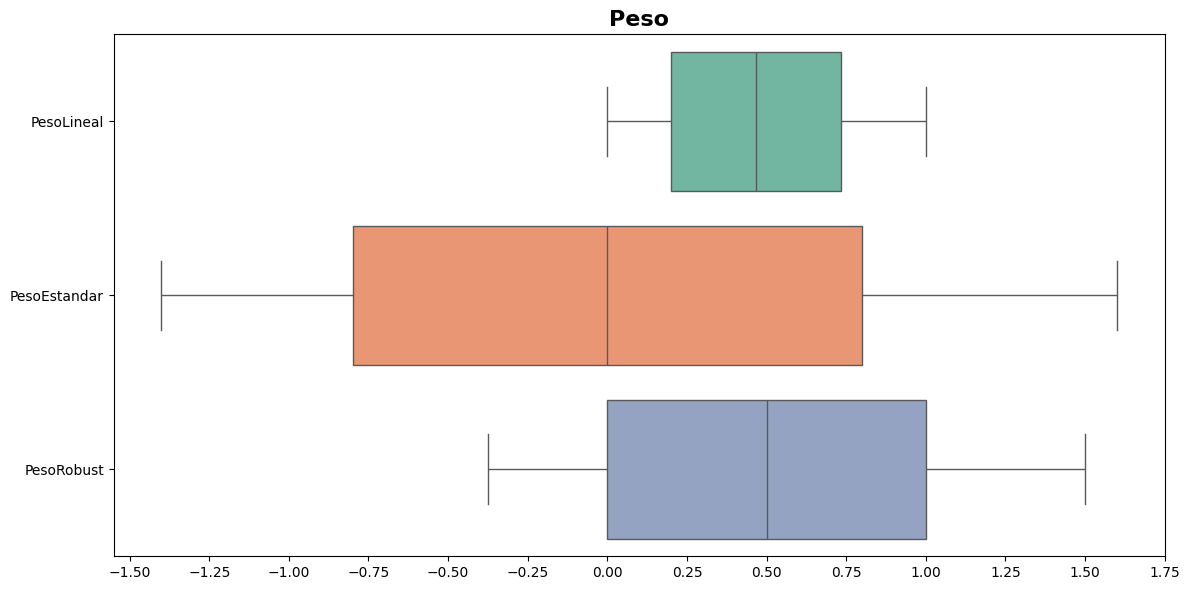

In [17]:
# Crear diagrama de caja de Altura
plt.figure(figsize=(12, 6))
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.3

df_melt_altura = df.melt(value_vars=["AlturaLineal", "AlturaEstandar", "AlturaRobust"], var_name="atributo", value_name="valor")
sns.boxplot(y="atributo", x="valor", data=df_melt_altura, palette="Set2")
plt.gca().xaxis.set_major_locator(MultipleLocator(0.25))
plt.title('Altura', fontsize=16, fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Crear diagrama de caja de Peso

plt.figure(figsize=(12, 6))
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.3

df_melt_peso = df.melt(value_vars=["PesoLineal", "PesoEstandar", "PesoRobust"], var_name="atributo", value_name="valor")
sns.boxplot(y="atributo", x="valor", data=df_melt_peso, palette="Set2")
plt.gca().xaxis.set_major_locator(MultipleLocator(0.25))
plt.title('Peso', fontsize=16, fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [18]:
# Creo dataframe
df = pd.DataFrame({
    "Altura": [1.65, 1.81, 1.70, 1.62, 1.74, 1.70, 1.80, 1.73, 1.68, 2.20],
    "Peso": [75, 86, 82, 78, 77, 87, 90, 83, 80, 120]
})

display(df)

,Altura,Peso
0,1.65,75
1,1.81,86
2,1.70,82
3,1.62,78
4,1.74,77
5,1.70,87
6,1.80,90
7,1.73,83
8,1.68,80
9,2.20,120


In [19]:
# Guardo variables de Altura
minAltura = df['Altura'].min()
maxAltura = df['Altura'].max()
mediaAltura = df['Altura'].mean()
desvioAltura = df['Altura'].std()
q1Altura = df['Altura'].quantile(0.25)
q3Altura = df['Altura'].quantile(0.75)
ircAltura = q3Altura - q1Altura

# Guardo variables de Peso
minPeso = df['Peso'].min()
maxPeso = df['Peso'].max()
mediaPeso = df['Peso'].mean()
desvioPeso = df['Peso'].std()
q1Peso = df['Peso'].quantile(0.25)
q3Peso = df['Peso'].quantile(0.75)
ircPeso = q3Peso - q1Peso

#Normalizo por MinMax
df['AlturaLineal']= (df['Altura']-minAltura)/(maxAltura-minAltura)
df['PesoLineal']= (df['Peso']-minPeso)/(maxPeso-minPeso)

# Normalizo Standard
df['AlturaEstandar']= (df['Altura']-mediaAltura)/desvioAltura
df['PesoEstandar']= (df['Peso']-mediaPeso)/desvioPeso

# Normalizo Robust
df['AlturaRobust']= (df['Altura']-q1Altura)/ircAltura
df['PesoRobust']= (df['Peso']-q1Peso)/ircPeso

display(df)

,Altura,Peso,AlturaLineal,PesoLineal,AlturaEstandar,PesoEstandar,AlturaRobust,PesoRobust
0,1.65,75,0.051724,0.000000,-0.685990,-0.836676,-0.35,-0.424242
1,1.81,86,0.327586,0.244444,0.285323,0.015494,1.25,0.909091
2,1.70,82,0.137931,0.155556,-0.382455,-0.294386,0.15,0.424242
3,1.62,78,0.000000,0.066667,-0.868112,-0.604266,-0.65,-0.060606
4,1.74,77,0.206897,0.044444,-0.139626,-0.681736,0.55,-0.181818
5,1.70,87,0.137931,0.266667,-0.382455,0.092964,0.15,1.030303
6,1.80,90,0.310345,0.333333,0.224616,0.325374,1.15,1.393939
7,1.73,83,0.189655,0.177778,-0.200333,-0.216916,0.45,0.545455
8,1.68,80,0.103448,0.111111,-0.503869,-0.449326,-0.05,0.181818
9,2.20,120,1.000000,1.000000,2.652901,2.649474,5.15,5.030303


C:\Users\gonza\AppData\Local\Temp\ipykernel_17264\2206684606.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y="atributo", x="valor", data=df_melt_altura, palette="Set2")


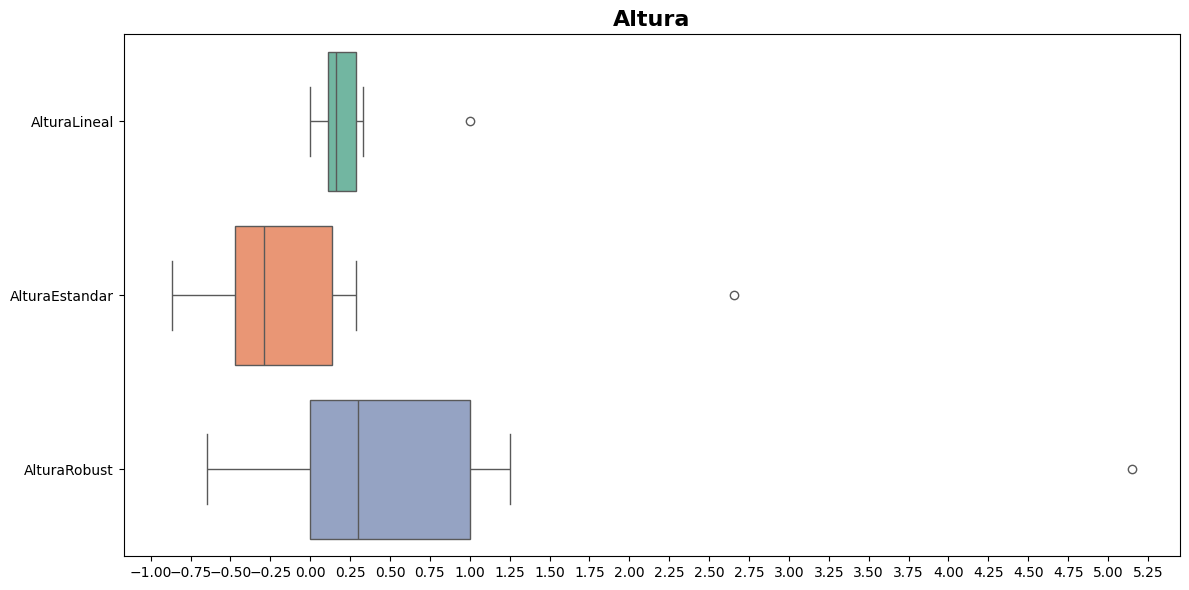

C:\Users\gonza\AppData\Local\Temp\ipykernel_17264\2206684606.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y="atributo", x="valor", data=df_melt_peso, palette="Set2")


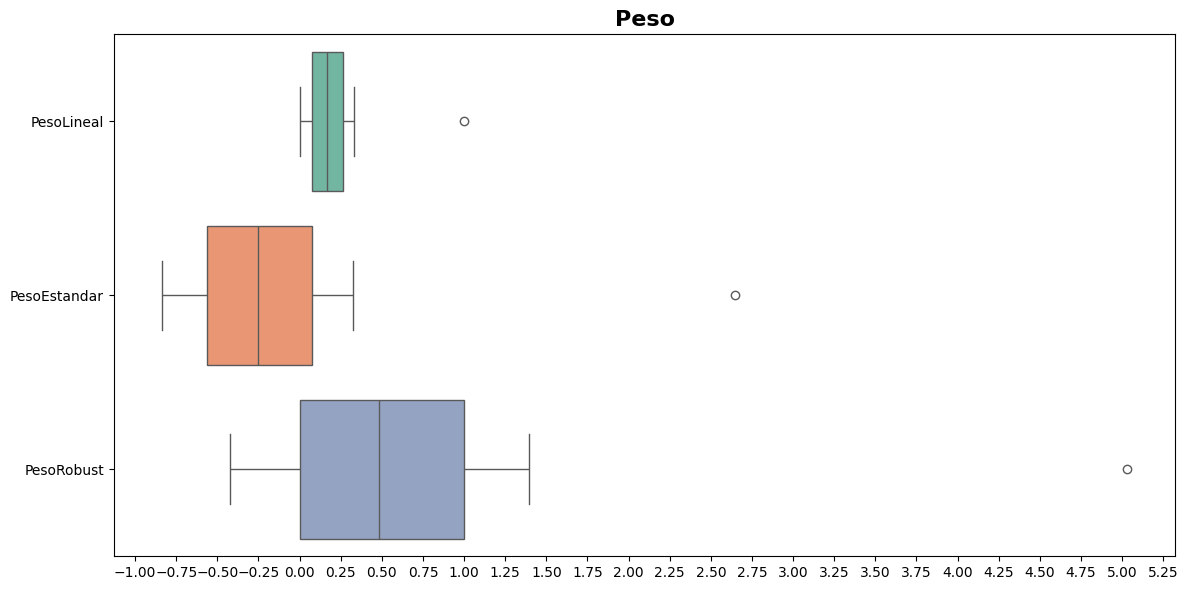

In [20]:
# Crear diagrama de caja de Altura
plt.figure(figsize=(12, 6))
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.3

df_melt_altura = df.melt(value_vars=["AlturaLineal", "AlturaEstandar", "AlturaRobust"], var_name="atributo", value_name="valor")
sns.boxplot(y="atributo", x="valor", data=df_melt_altura, palette="Set2")
plt.gca().xaxis.set_major_locator(MultipleLocator(0.25))
plt.title('Altura', fontsize=16, fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Crear diagrama de caja de Peso

plt.figure(figsize=(12, 6))
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.3

df_melt_peso = df.melt(value_vars=["PesoLineal", "PesoEstandar", "PesoRobust"], var_name="atributo", value_name="valor")
sns.boxplot(y="atributo", x="valor", data=df_melt_peso, palette="Set2")
plt.gca().xaxis.set_major_locator(MultipleLocator(0.25))
plt.title('Peso', fontsize=16, fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()